In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline

1) Utilize Linear(first degree polynomial) and spline interpolation to see which method is the best fit for this data, i.e. does this justify linear regression. 

In [ ]:
def merger(pathCal, pathMass):
    df1 = pd.read_csv(pathCal)
    df2 = pd.read_csv(pathMass)

    df1["Date"] = pd.to_datetime(df1["Date"])
    df2["Date"] = pd.to_datetime(df2["Date"])

    daily_calories = df1.groupby("Date", as_index=False)["Calories"].sum()
    daily_calories["Calories"] = np.ceil(daily_calories["Calories"]).astype(int)

    daily_weight = df2.groupby("Date", as_index=False)["Weight"].mean()

    all_dates = pd.DataFrame({
        "Date": pd.date_range(
            start=min(df1["Date"].min(), df2["Date"].min()),
            end=max(df1["Date"].max(), df2["Date"].max())
        )
    })

    merged_df = all_dates \
        .merge(daily_calories, on="Date", how="left") \
        .merge(daily_weight, on="Date", how="left")

    merged_df["day"] = (merged_df["Date"] - merged_df["Date"].min()).dt.days

    return merged_df

calories_data = "Calories.csv"
weight_data = "Weight.csv"
merger(calories_data,weight_data).to_csv("output.csv", index = False)



── Weight Interpolation ──
  Linear → MAE: 0.381,  RMSE: 0.491
  Spline → MAE: 0.481,  RMSE: 0.664


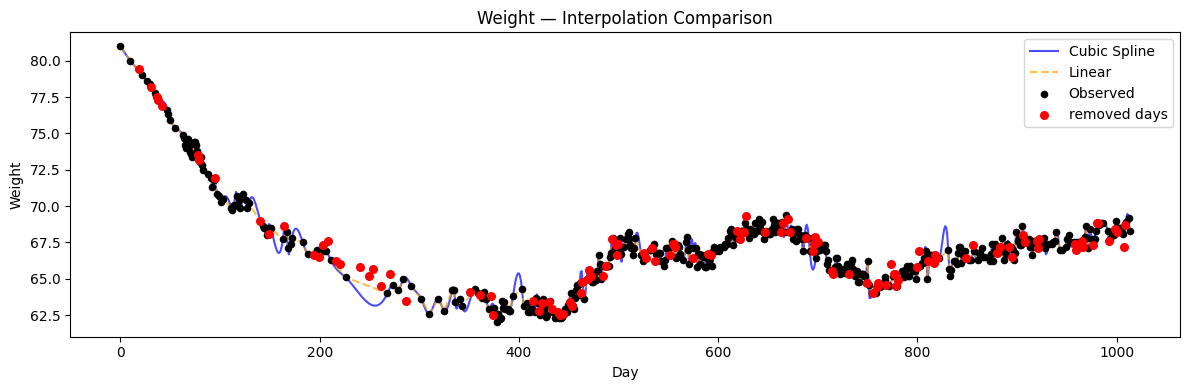


── Calories Interpolation ──
  Linear → MAE: 230.066,  RMSE: 304.593
  Spline → MAE: 289.430,  RMSE: 388.616


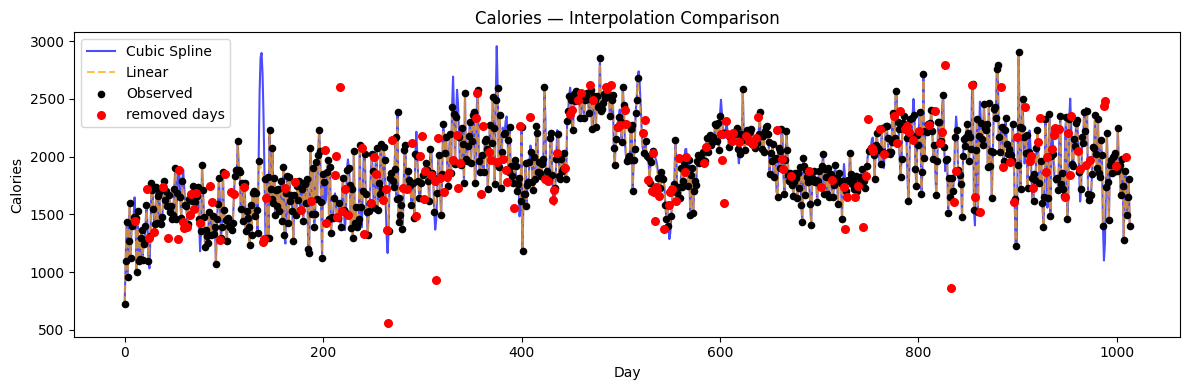

In [20]:
def interpolate_and_compare(df):
    results = {}

    for column in ["Weight", "Calories"]:
        known = df[df[column].notna()].copy()
        days = known["day"].values
        values = known[column].values

        # remove 20% for error comparison
        np.random.seed(42)
        test_idx = np.sort(np.random.choice(len(days), size=len(days)//5, replace=False))
        train_days = np.delete(days, test_idx)
        train_values = np.delete(values, test_idx)
        test_days = days[test_idx]
        true_values = values[test_idx]

        # Linear
        linear_pred = np.interp(test_days, train_days, train_values)

        # Cubic spline
        cs = CubicSpline(train_days, train_values)
        spline_pred = cs(test_days)

        # Errors
        linear_mae  = np.mean(np.abs(linear_pred - true_values))
        spline_mae  = np.mean(np.abs(spline_pred - true_values))
        linear_rmse = np.sqrt(np.mean((linear_pred - true_values) ** 2))
        spline_rmse = np.sqrt(np.mean((spline_pred - true_values) ** 2))

        print(f"\n── {column} Interpolation ──")
        print(f"  Linear → MAE: {linear_mae:.3f},  RMSE: {linear_rmse:.3f}")
        print(f"  Spline → MAE: {spline_mae:.3f},  RMSE: {spline_rmse:.3f}")

        # Fill all days using both methods
        all_days = df["day"].values
        df[f"{column}_linear"] = np.interp(all_days, train_days, train_values)
        df[f"{column}_spline"] = cs(all_days)

        results[column] = {
            "linear_mae": linear_mae, "spline_mae": spline_mae,
            "linear_rmse": linear_rmse, "spline_rmse": spline_rmse,
            "spline_fn": cs
        }

        # Plot
        plt.figure(figsize=(12, 4))
        plt.plot(all_days, df[f"{column}_spline"], label="Cubic Spline", color="blue", alpha=0.7)
        plt.plot(all_days, df[f"{column}_linear"], label="Linear",       color="orange", alpha=0.7, linestyle="--")
        plt.scatter(days, values, label="Observed", color="black", zorder=5, s=20)
        plt.scatter(test_days, true_values, label="removed days", color="red", zorder=6, s=30)
        plt.xlabel("Day")
        plt.ylabel(column)
        plt.title(f"{column} — Interpolation Comparison")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df, results

df1 = pd.read_csv("output.csv")
df2, results = interpolate_and_compare(df)
df2.to_csv("spline.csv", index = False)

Since MAE and RMSE for linear 

In [21]:
#Helper functions

def differentiate(f, x, h=0.01):
    """5-point stencil"""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12*h)

def best_degree(xs, ys, max_degree=12):
    """polynomial degree selection"""
    n = len(ys)
    best_deg = 1
    best_bic = np.inf

    for deg in range(1, max_degree + 1):
        coeffs = np.polyfit(xs, ys, deg)
        f = np.poly1d(coeffs)
        residuals = ys - f(xs)
        sse = np.sum(residuals ** 2)
        bic = n * np.log(sse / n) + deg * np.log(n)

        if bic < best_bic:
            best_bic = bic
            best_deg = deg

    return best_deg

In [22]:
def detect_phases(df, slope_threshold=0.005):
    days = df["day"].values.astype(float)
    weight = df["Weight_linear"].values

    # Fit best polynomial to weight
    degree = best_degree(days, weight)
    coeffs = np.polyfit(days, weight, degree)
    f = np.poly1d(coeffs)

    # derivative at each day
    x = np.linspace(days.min(), days.max(), len(days))
    d = differentiate(f, x)

    # Classify each day
    phases = []
    for slope in d:
        if slope > slope_threshold:
            phases.append("bulk")
        elif slope < -slope_threshold:
            phases.append("cut")
        else:
            phases.append("maintenance")

    df["phase"] = phases
    df["fitted_weight"] = f(x)
    df["weight_slope"] = d

    # Find transition points (where phase changes)
    transitions = []
    for i in range(1, len(phases)):
        if phases[i] != phases[i-1]:
            transitions.append((df["Date"].iloc[i], phases[i-1], phases[i]))

    print("\nPhase transitions:")
    for date, prev, curr in transitions:
        print(f"  {date.date()}  {prev} > {curr}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Weight + fitted curve + phase shading
    colors = {"bulk": "green", "cut": "red", "maintenance": "gray"}
    prev_phase = phases[0]
    start_idx  = 0

    for i in range(1, len(phases)):
        if phases[i] != prev_phase or i == len(phases) - 1:
            ax1.axvspan(
                df["Date"].iloc[start_idx],
                df["Date"].iloc[i],
                alpha=0.15,
                color=colors[prev_phase],
                label=prev_phase if prev_phase not in [p for p, _ in [(prev_phase, None)]] else ""
            )
            start_idx = i
            prev_phase = phases[i]

    ax1.scatter(df["Date"], df["Weight_linear"], color="black", s=10, alpha=0.5, label="Observed weight")
    ax1.plot(df["Date"], df["fitted_weight"], color="blue", linewidth=2, label=f"Poly fit (deg {degree})")
    ax1.set_ylabel("Weight (kg)")
    ax1.set_title("Weight Trajectory with Phase Detection")
    ax1.legend()

    # Derivative plot
    ax2.plot(df["Date"], d, color="purple", linewidth=1.5, label="dW/dt")
    ax2.axhline(y= slope_threshold, color="green", linestyle="--", alpha=0.7, label=f"+{slope_threshold} threshold")
    ax2.axhline(y=-slope_threshold, color="red",   linestyle="--", alpha=0.7, label=f"-{slope_threshold} threshold")
    ax2.axhline(y=0, color="black", linestyle="-", alpha=0.3)
    ax2.set_ylabel("dW/dt (kg/day)")
    ax2.set_xlabel("Date")
    ax2.set_title("Weight Slope (Numerical Derivative)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df, transitions

df1 = "spline.csv"
df2, transitions = detect_phases(df1)

TypeError: string indices must be integers, not 'str'